In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

In [3]:
df_train = pd.read_csv('./data/train.csv')
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df_train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [ ]:
# PHASE 1: EXPLORATORY DATA ANALYSIS
print("="*80)
print("PHASE 1: EXPLORATORY DATA ANALYSIS")
print("="*80)

In [4]:
# 1.1 Data Summary and Overview
print("\n1.1 DATA SUMMARY AND OVERVIEW")
print("-" * 80)
print(f"Dataset Shape: {df_train.shape}")
print(f"\nData Types:\n{df_train.dtypes.value_counts()}")
print(f"\nMemory Usage: {df_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFirst 10 rows:")
df_train.head(10)


1.1 DATA SUMMARY AND OVERVIEW
--------------------------------------------------------------------------------
Dataset Shape: (1460, 81)

Data Types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Memory Usage: 3.43 MB

First 10 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,


1.2 MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------

Total columns with missing values: 19

Missing Data Summary:
      Column  Missing_Count  Missing_Percentage
      PoolQC           1453               99.52
 MiscFeature           1406               96.30
       Alley           1369               93.77
       Fence           1179               80.75
  MasVnrType            872               59.73
 FireplaceQu            690               47.26
 LotFrontage            259               17.74
  GarageType             81                5.55
 GarageYrBlt             81                5.55
GarageFinish             81                5.55
  GarageQual             81                5.55
  GarageCond             81                5.55
BsmtExposure             38                2.60
BsmtFinType2             38                2.60
    BsmtQual             37                2.53
    BsmtCond             37                2.53
BsmtFinType1

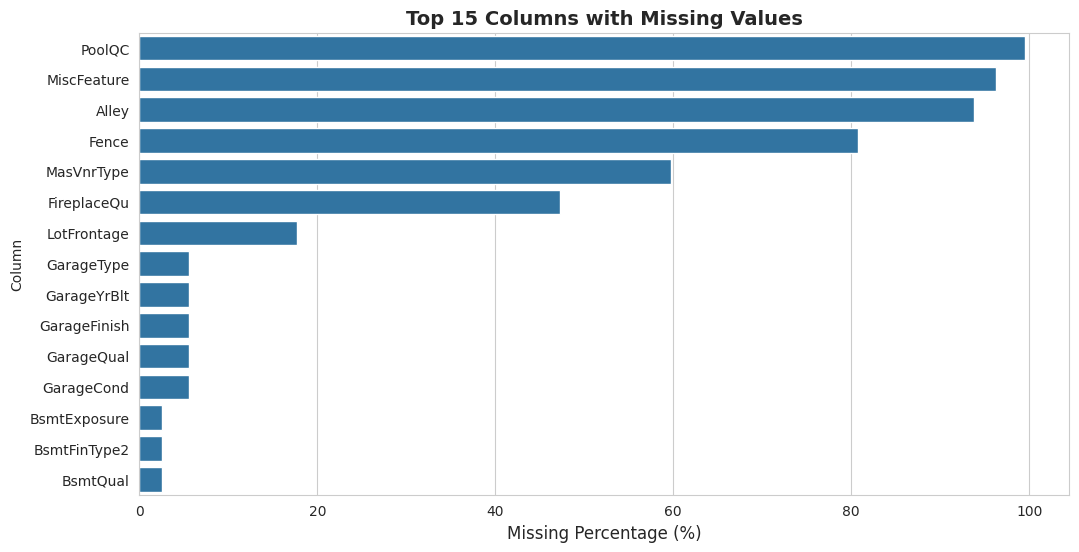

In [5]:
# 1.2 Missing Values Analysis
print("\n1.2 MISSING VALUES ANALYSIS")
print("-" * 80)
missing_data = pd.DataFrame({
    'Column': df_train.columns,
    'Missing_Count': df_train.isnull().sum(),
    'Missing_Percentage': (df_train.isnull().sum() / len(df_train) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(f"\nTotal columns with missing values: {len(missing_data)}")
print("\nMissing Data Summary:")
print(missing_data.to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=missing_data.head(15), x='Missing_Percentage', y='Column', ax=ax)
plt.title('Top 15 Columns with Missing Values', fontsize=14, fontweight='bold')
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.show()

# Store for later reference
missing_summary = missing_data.copy()


1.3 TARGET VARIABLE (SalePrice) ANALYSIS
--------------------------------------------------------------------------------

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8809
Kurtosis: 6.5098


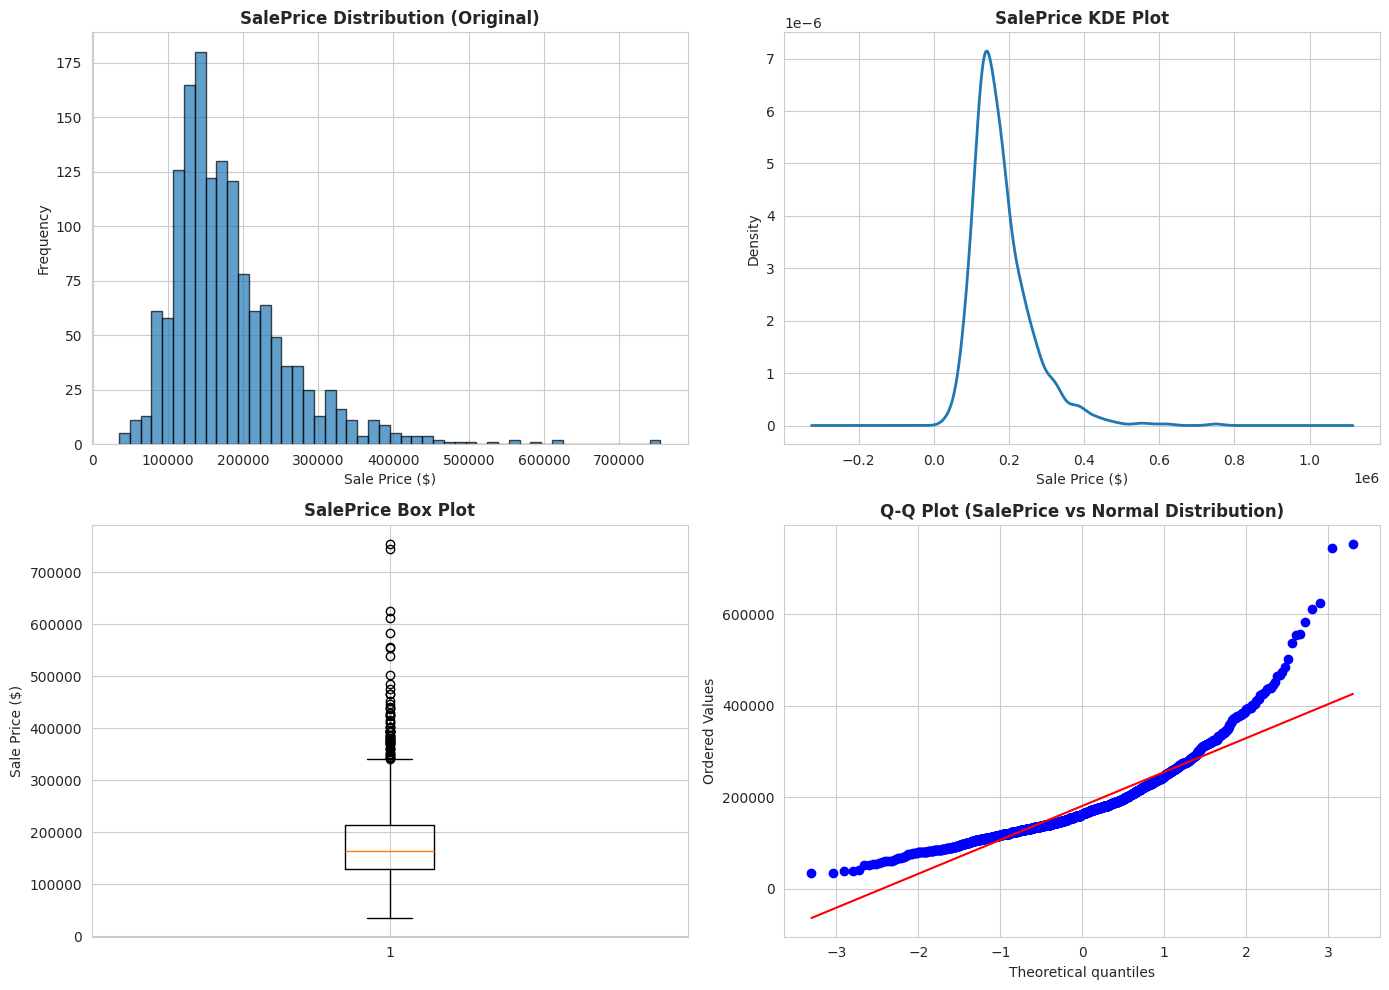


After Log Transform:
Skewness: 0.1212
Kurtosis: 0.8026


In [6]:
# 1.3 Target Variable (SalePrice) Analysis
print("\n1.3 TARGET VARIABLE (SalePrice) ANALYSIS")
print("-" * 80)
print(f"\nSalePrice Statistics:")
print(df_train['SalePrice'].describe())
print(f"\nSkewness: {skew(df_train['SalePrice']):.4f}")
print(f"Kurtosis: {kurtosis(df_train['SalePrice']):.4f}")

# Visualize SalePrice distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df_train['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('SalePrice Distribution (Original)', fontweight='bold')
axes[0, 0].set_xlabel('Sale Price ($)')
axes[0, 0].set_ylabel('Frequency')

# KDE plot
df_train['SalePrice'].plot(kind='kde', ax=axes[0, 1], linewidth=2)
axes[0, 1].set_title('SalePrice KDE Plot', fontweight='bold')
axes[0, 1].set_xlabel('Sale Price ($)')

# Box plot
axes[1, 0].boxplot(df_train['SalePrice'])
axes[1, 0].set_title('SalePrice Box Plot', fontweight='bold')
axes[1, 0].set_ylabel('Sale Price ($)')

# Q-Q plot for normality check
stats.probplot(df_train['SalePrice'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (SalePrice vs Normal Distribution)', fontweight='bold')

plt.tight_layout()
plt.show()

# Log transformation
print(f"\nAfter Log Transform:")
print(f"Skewness: {skew(np.log1p(df_train['SalePrice'])):.4f}")
print(f"Kurtosis: {kurtosis(np.log1p(df_train['SalePrice'])):.4f}")

# Store original price for later
df_train['SalePrice_Original'] = df_train['SalePrice']
df_train['SalePrice_Log'] = np.log1p(df_train['SalePrice'])


1.4 NUMERICAL FEATURES ANALYSIS
--------------------------------------------------------------------------------
Number of numerical features: 36
Number of categorical features: 43

Numerical columns: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']...

Numerical Features Summary:
       MSSubClass  LotFrontage    LotArea  OverallQual  OverallCond  \
count      1460.0      1201.00    1460.00      1460.00      1460.00   
mean         56.9        70.05   10516.83         6.10         5.58   
std          42.3        24.28    9981.26         1.38         1.11   
min          20.0        21.00    1300.00         1.00         1.00   
25%          20.0        59.00    7553.50         5.00         5.00   
50%          50.0        69.00    9478.50         6.00         5.00   
75%          70.0        80.00   11601.50         7.00         6.00   
max         190.0       313.00  215245.00        10.00  

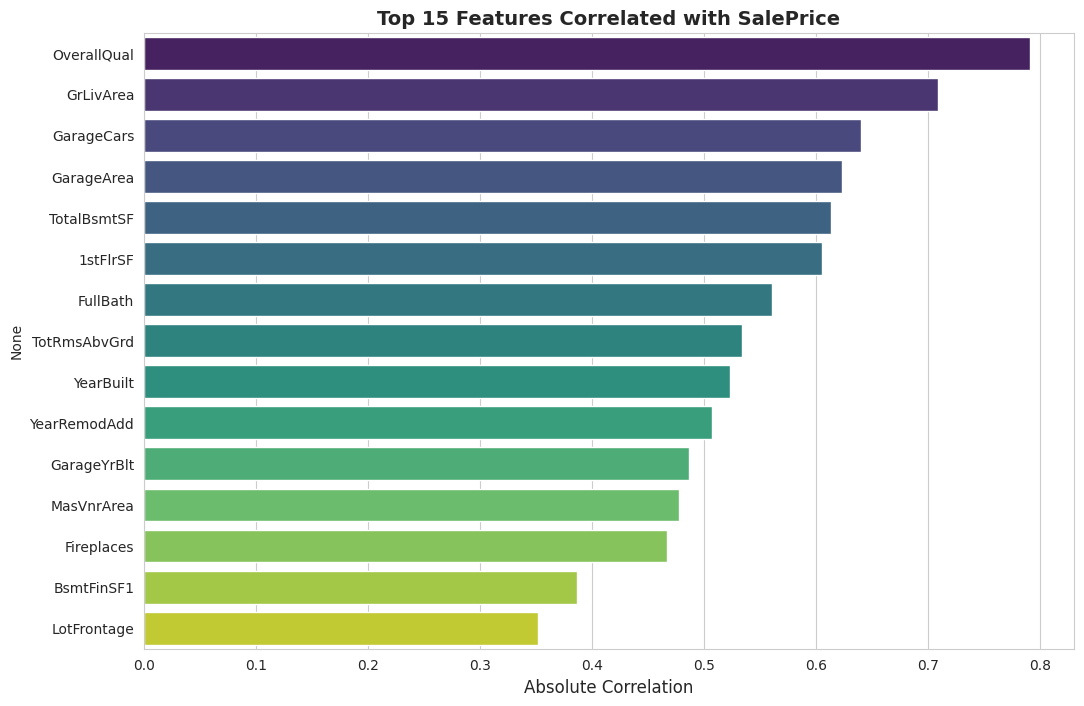

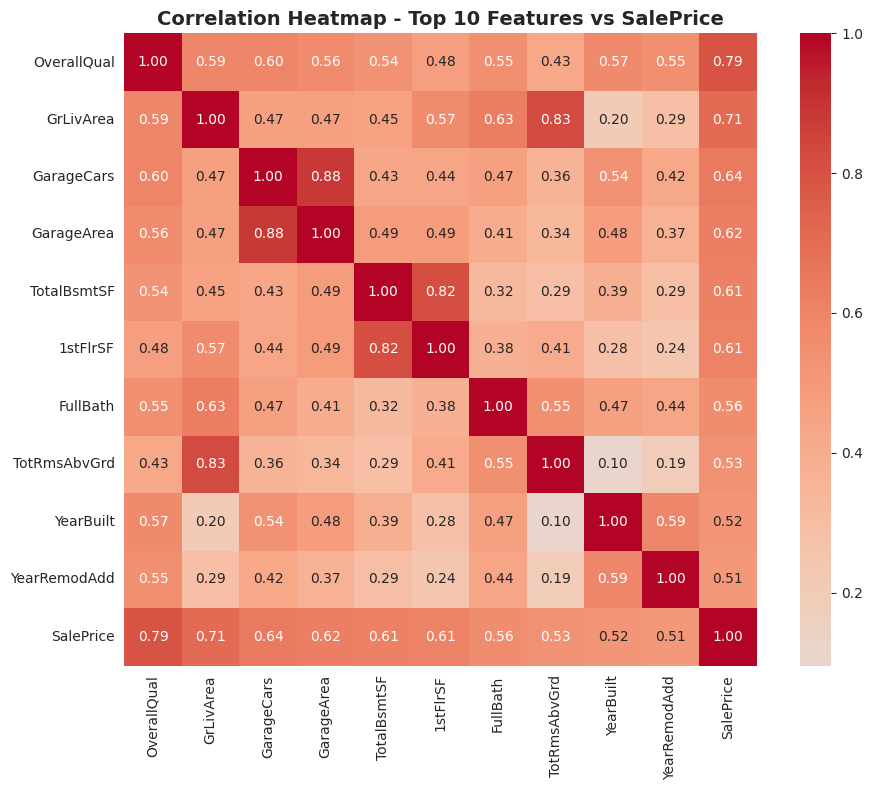


Skewness Analysis for Numerical Features:
      Feature  Skewness
      MiscVal 24.451640
     PoolArea 14.813135
      LotArea 12.195142
    3SsnPorch 10.293752
 LowQualFinSF  9.002080
 KitchenAbvGr  4.483784
   BsmtFinSF2  4.250888
  ScreenPorch  4.117977
 BsmtHalfBath  4.099186
EnclosedPorch  3.086696
   MasVnrArea  2.666326
  OpenPorchSF  2.361912
  LotFrontage  2.160866
   BsmtFinSF1  1.683771
   WoodDeckSF  1.539792

Highly skewed features (|skewness| > 1.0): 19


In [7]:
# 1.4 Numerical Features Analysis
print("\n1.4 NUMERICAL FEATURES ANALYSIS")
print("-" * 80)

# Identify numerical and categorical columns
numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()

# Remove target variable and ID from numerical columns
if 'Id' in numerical_cols:
    numerical_cols.remove('Id')
if 'SalePrice' in numerical_cols:
    numerical_cols.remove('SalePrice')
if 'SalePrice_Original' in numerical_cols:
    numerical_cols.remove('SalePrice_Original')
if 'SalePrice_Log' in numerical_cols:
    numerical_cols.remove('SalePrice_Log')

print(f"Number of numerical features: {len(numerical_cols)}")
print(f"Number of categorical features: {len(categorical_cols)}")
print(f"\nNumerical columns: {numerical_cols[:10]}...")

# Summary statistics for numerical features
print(f"\nNumerical Features Summary:")
print(df_train[numerical_cols].describe().round(2))

# Correlation with SalePrice
print(f"\nTop 15 Features Correlated with SalePrice:")
correlations = df_train[numerical_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
print(correlations.head(15))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))
top_corr_features = correlations.head(15)
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, ax=ax, palette='viridis')
plt.title('Top 15 Features Correlated with SalePrice', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation', fontsize=12)
plt.show()

# Correlation heatmap for top features
top_features = correlations.head(10).index.tolist() + ['SalePrice']
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[top_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap - Top 10 Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify skewed features
print(f"\nSkewness Analysis for Numerical Features:")
skewness_data = pd.DataFrame({
    'Feature': numerical_cols,
    'Skewness': [skew(df_train[col].dropna()) for col in numerical_cols]
})
skewness_data = skewness_data.reindex(skewness_data['Skewness'].abs().sort_values(ascending=False).index)
print(skewness_data.head(15).to_string(index=False))

# Store for later
highly_skewed = skewness_data[skewness_data['Skewness'].abs() > 1.0]['Feature'].tolist()
print(f"\nHighly skewed features (|skewness| > 1.0): {len(highly_skewed)}")


1.5 CATEGORICAL FEATURES ANALYSIS
--------------------------------------------------------------------------------
Categorical Features (43):
  MSZoning: 5 unique values
  Street: 2 unique values
  Alley: 2 unique values
  LotShape: 4 unique values
  LandContour: 4 unique values


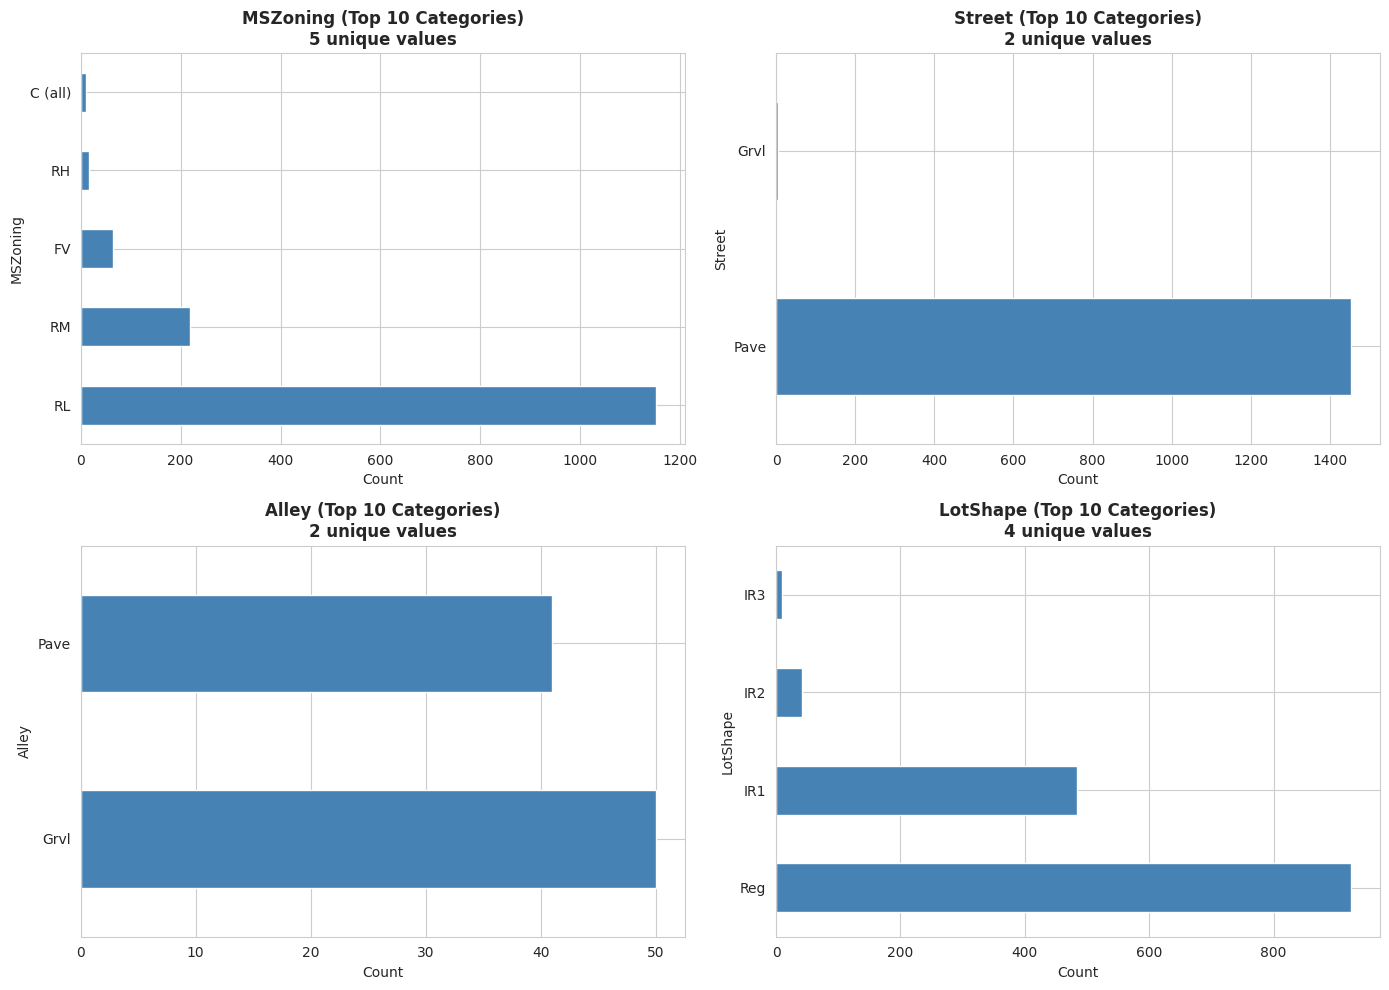


Mean SalePrice by Neighborhood:
                       mean    median  count
Neighborhood                                
NoRidge       335295.317073  301500.0     41
NridgHt       316270.623377  315000.0     77
StoneBr       310499.000000  278000.0     25
Timber        242247.447368  228475.0     38
Veenker       238772.727273  218000.0     11
Somerst       225379.837209  225500.0     86
ClearCr       212565.428571  200250.0     28
Crawfor       210624.725490  200624.0     51
CollgCr       197965.773333  197200.0    150
Blmngtn       194870.882353  191000.0     17
Gilbert       192854.506329  181000.0     79
NWAmes        189050.068493  182900.0     73
SawyerW       186555.796610  179900.0     59
Mitchel       156270.122449  153500.0     49
NAmes         145847.080000  140000.0    225
NPkVill       142694.444444  146000.0      9
SWISU         142591.360000  139500.0     25
Blueste       137500.000000  137500.0      2
Sawyer        136793.135135  135000.0     74
OldTown       128225.3

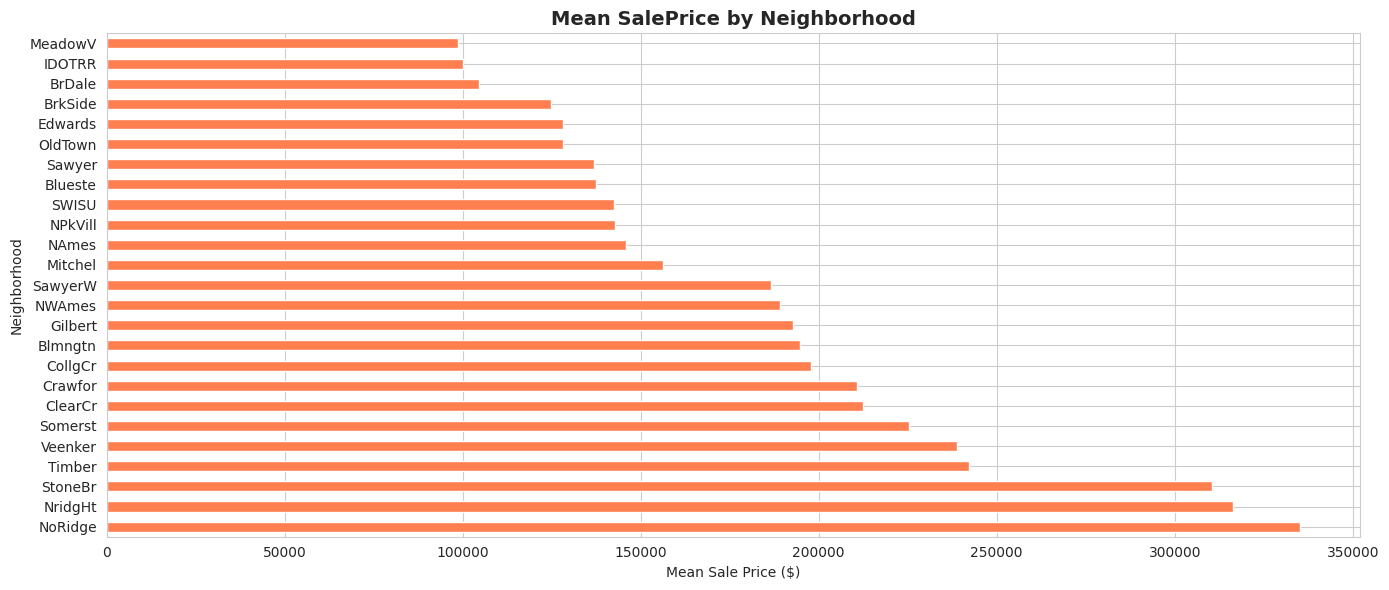


Categorical Feature Cardinality Summary:
      Feature  Unique_Values Most_Common_Value  Most_Common_Count
 Neighborhood             25             NAmes                225
  Exterior2nd             16           VinylSd                504
  Exterior1st             15           VinylSd                515
   Condition1              9              Norm               1260
     SaleType              9                WD               1267
   HouseStyle              8            1Story                726
     RoofMatl              8           CompShg               1434
   Condition2              8              Norm               1445
   Functional              7               Typ               1360
 BsmtFinType2              6               Unf               1256
    RoofStyle              6             Gable               1141
 BsmtFinType1              6               Unf                430
SaleCondition              6            Normal               1198
      Heating              6      

In [8]:
# 1.5 Categorical Features Analysis
print("\n1.5 CATEGORICAL FEATURES ANALYSIS")
print("-" * 80)

print(f"Categorical Features ({len(categorical_cols)}):")
for col in categorical_cols[:5]:
    unique_count = df_train[col].nunique()
    print(f"  {col}: {unique_count} unique values")

# Analyze cardinality and unique value distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:4]):
    unique_count = df_train[col].nunique()
    value_counts = df_train[col].value_counts().head(10)
    
    ax = axes[idx]
    value_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{col} (Top 10 Categories)\n{unique_count} unique values', fontweight='bold')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

# Mean SalePrice by categorical feature (for top feature with moderate cardinality)
if 'Neighborhood' in categorical_cols:
    print(f"\nMean SalePrice by Neighborhood:")
    neighborhood_prices = df_train.groupby('Neighborhood')['SalePrice'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    print(neighborhood_prices)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    neighborhood_prices['mean'].plot(kind='barh', ax=ax, color='coral')
    plt.title('Mean SalePrice by Neighborhood', fontsize=14, fontweight='bold')
    plt.xlabel('Mean Sale Price ($)')
    plt.tight_layout()
    plt.show()

# Cardinality summary
print(f"\nCategorical Feature Cardinality Summary:")
cardinality_data = pd.DataFrame({
    'Feature': categorical_cols,
    'Unique_Values': [df_train[col].nunique() for col in categorical_cols],
    'Most_Common_Value': [df_train[col].value_counts().index[0] for col in categorical_cols],
    'Most_Common_Count': [df_train[col].value_counts().values[0] for col in categorical_cols]
})
cardinality_data = cardinality_data.sort_values('Unique_Values', ascending=False)
print(cardinality_data.to_string(index=False))


1.6 OUTLIER ANALYSIS
--------------------------------------------------------------------------------
Outlier Detection (IQR method) for key features:
  SalePrice: 61 outliers (4.18%)
  GrLivArea: 31 outliers (2.12%)
  LotArea: 69 outliers (4.73%)
  OverallQual: 2 outliers (0.14%)

Extreme Outliers (SalePrice vs GrLivArea):
  Large area but low price: 2 properties
        Id  GrLivArea  SalePrice  OverallQual  OverallCond
523    524       4676     184750           10            5
1298  1299       5642     160000           10            5


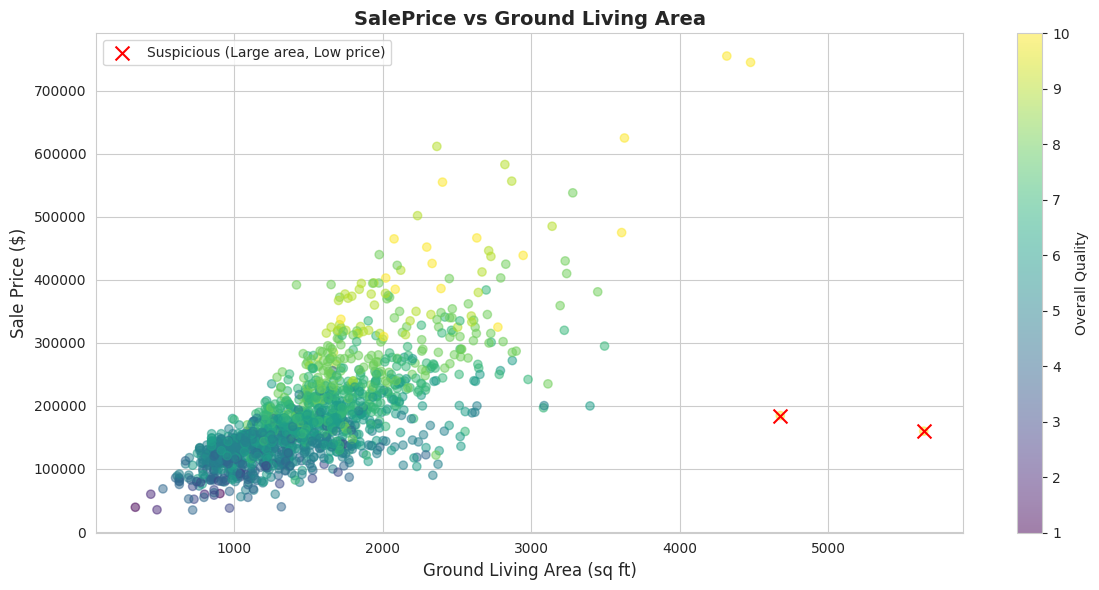


Total outliers to investigate: 2


In [9]:
# 1.6 Outlier Analysis
print("\n1.6 OUTLIER ANALYSIS")
print("-" * 80)

# Univariate outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Check for outliers in key features
outlier_features = ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual']
print(f"Outlier Detection (IQR method) for key features:")
for feat in outlier_features:
    if feat in df_train.columns:
        outliers = detect_outliers_iqr(df_train, feat)
        print(f"  {feat}: {len(outliers)} outliers ({len(outliers)/len(df_train)*100:.2f}%)")

# Identify extreme outliers in SalePrice vs GrLivArea
print(f"\nExtreme Outliers (SalePrice vs GrLivArea):")
# Homes with very low price but large area (possible data errors)
suspicious = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)]
print(f"  Large area but low price: {len(suspicious)} properties")
print(suspicious[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'OverallCond']].head())

# Visualize relationship
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df_train['GrLivArea'], df_train['SalePrice'], alpha=0.5, c=df_train['OverallQual'], cmap='viridis')
if len(suspicious) > 0:
    ax.scatter(suspicious['GrLivArea'], suspicious['SalePrice'], color='red', s=100, marker='x', label='Suspicious (Large area, Low price)')
ax.set_xlabel('Ground Living Area (sq ft)', fontsize=12)
ax.set_ylabel('Sale Price ($)', fontsize=12)
ax.set_title('SalePrice vs Ground Living Area', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Overall Quality')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal outliers to investigate: {len(suspicious)}")

In [10]:
print("\n" + "="*80)
print("PHASE 2: DATA CLEANING")
print("="*80)

# Create a working copy for cleaning
df_clean = df_train.copy()

# 2.1 Handle Missing Values - Structural NAs in categorical columns
print("\n2.1 HANDLING MISSING VALUES")
print("-" * 80)

# Columns with structural NA (no such feature) - encode as "None"
structural_na_cols = {
    'Alley': 'None',           # No alley access
    'Basement Classes': 'None',
    'BsmtQual': 'None',
    'BsmtCond': 'None',
    'BsmtExposure': 'None',
    'BsmtFinType1': 'None',
    'BsmtFinType2': 'None',
    'FireplaceQu': 'None',  # No fireplace
    'GarageType': 'None',   # No garage
    'GarageYrBlt': 'None',
    'GarageFinish': 'None',
    'GarageQual': 'None',
    'GarageCond': 'None',
    'PoolQC': 'None',       # No pool
    'Fence': 'None',        # No fence
    'MiscFeature': 'None'   # No misc feature
}

# Map structural NA columns more carefully
basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
garage_cols = ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']

# Fill structural NAs with 'None' for categorical features
for col in basement_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')
        
for col in garage_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')

# Other structural NA columns
for col in ['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')

print("Filled structural NAs in basement, garage, and outdoor feature columns with 'None'")

# 2.2 Handle LotFrontage - impute by Neighborhood median
print("\n2.2 HANDLING LotFrontage (Neighborhood-based imputation)")
if 'LotFrontage' in df_clean.columns:
    missing_lot_frontage = df_clean['LotFrontage'].isnull().sum()
    print(f"Missing LotFrontage: {missing_lot_frontage} ({missing_lot_frontage/len(df_clean)*100:.2f}%)")
    
    if 'Neighborhood' in df_clean.columns:
        df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"After imputation: {df_clean['LotFrontage'].isnull().sum()} missing values remain")

# 2.3 Handle remaining numerical missing values (if any)
print("\n2.3 HANDLING REMAINING MISSING VALUES")
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print(f"Remaining missing values:")
    print(remaining_missing)
    
    # Fill numerical columns with median
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            print(f"  {col}: filled with median ({median_val:.2f})")
else:
    print("No remaining missing values!")

print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")


PHASE 2: DATA CLEANING

2.1 HANDLING MISSING VALUES
--------------------------------------------------------------------------------
Filled structural NAs in basement, garage, and outdoor feature columns with 'None'

2.2 HANDLING LotFrontage (Neighborhood-based imputation)
Missing LotFrontage: 259 (17.74%)
After imputation: 0 missing values remain

2.3 HANDLING REMAINING MISSING VALUES
Remaining missing values:
MasVnrType    872
MasVnrArea      8
Electrical      1
dtype: int64
  MasVnrArea: filled with median (0.00)

Missing values after cleaning: 873


In [11]:
# 2.4 Handle Outliers
print("\n2.4 HANDLING OUTLIERS")
print("-" * 80)

# Remove data entry errors (houses with GrLivArea > 4000 and price < 300000)
print(f"Dataset shape before outlier removal: {df_clean.shape}")
df_clean = df_clean.drop(suspicious.index, errors='ignore')
print(f"Dataset shape after removing extreme outliers: {df_clean.shape}")
print(f"Removed {1460 - len(df_clean)} suspicious records (large area but very low price)")

# 2.5 Fix Data Type Inconsistencies
print("\n2.5 FIXING DATA TYPES")
print("-" * 80)

# Ordinal categorical features (quality ratings) - keep as categorical for now, will encode later
ordinal_features = {
    'ExterQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'HeatingQC': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
}

print("Identified ordinal features (will encode later in Phase 3)")
print(f"Ordinal features: {list(ordinal_features.keys())}")

# Ensure categorical columns are of type 'object'
categorical_cols_clean = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols_clean:
    df_clean[col] = df_clean[col].astype('object')

print(f"\nData types corrected. Categorical columns: {len(categorical_cols_clean)}")
print(f"Data cleaning complete! Clean dataset shape: {df_clean.shape}")


2.4 HANDLING OUTLIERS
--------------------------------------------------------------------------------
Dataset shape before outlier removal: (1460, 83)
Dataset shape after removing extreme outliers: (1458, 83)
Removed 2 suspicious records (large area but very low price)

2.5 FIXING DATA TYPES
--------------------------------------------------------------------------------
Identified ordinal features (will encode later in Phase 3)
Ordinal features: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

Data types corrected. Categorical columns: 44
Data cleaning complete! Clean dataset shape: (1458, 83)


In [12]:
print("\n" + "="*80)
print("PHASE 3: FEATURE ENGINEERING")
print("="*80)

# Create feature engineering dataset
df_fe = df_clean.copy()

# 3.1 Numerical Feature Transformations
print("\n3.1 NUMERICAL FEATURE TRANSFORMATIONS")
print("-" * 80)

# Log transform right-skewed features
skewed_features = ['LotArea', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 
                    'LotFrontage', 'BsmtUnfSF', 'PoolArea']

for feat in skewed_features:
    if feat in df_fe.columns:
        df_fe[f'{feat}_Log'] = np.log1p(df_fe[feat])

print(f"Created log-transformed versions of {len(skewed_features)} skewed features")

# Box-Cox transformation for normalization (use PowerTransformer)
pt = PowerTransformer(method='box-cox', standardize=False)

# Apply to positive numerical features only
positive_features = [col for col in df_fe.select_dtypes(include=[np.number]).columns 
                     if df_fe[col].min() > 0 and col not in ['Id', 'SalePrice', 'SalePrice_Original', 'SalePrice_Log']]

# Sample a few for Box-Cox
boxcox_features = ['LotArea', 'GrLivArea', 'TotalBsmtSF']
for feat in boxcox_features:
    if feat in df_fe.columns and df_fe[feat].min() > 0:
        try:
            df_fe[f'{feat}_BoxCox'] = pt.fit_transform(df_fe[[feat]])
        except:
            pass

print(f"Applied Box-Cox transformation to {len(boxcox_features)} features")

# Polynomial features for key predictors
print("\nCreating polynomial features for key predictors...")
for feat in ['OverallQual', 'OverallCond', 'GrLivArea']:
    if feat in df_fe.columns:
        df_fe[f'{feat}^2'] = df_fe[feat] ** 2
        df_fe[f'{feat}^3'] = df_fe[feat] ** 3

print("Created polynomial features (degree 2-3) for key predictors")


PHASE 3: FEATURE ENGINEERING

3.1 NUMERICAL FEATURE TRANSFORMATIONS
--------------------------------------------------------------------------------
Created log-transformed versions of 7 skewed features
Applied Box-Cox transformation to 3 features

Creating polynomial features for key predictors...
Created polynomial features (degree 2-3) for key predictors


In [13]:
# 3.2 Domain-Informed Feature Creation
print("\n3.2 DOMAIN-INFORMED FEATURE CREATION")
print("-" * 80)

# Age-related features
df_fe['Age'] = df_fe['YrSold'] - df_fe['YearBuilt']
df_fe['RemodAge'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
df_fe['HasRemodel'] = (df_fe['YearRemodAdd'] > df_fe['YearBuilt']).astype(int)
df_fe['YearsOld'] = df_fe['Age']
df_fe['Is_NewHouse'] = (df_fe['Age'] <= 5).astype(int)
df_fe['IsRecent'] = (df_fe['Age'] < 10).astype(int)

# Area-related features and ratios
df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']
df_fe['TotalBath'] = df_fe['BsmtFullBath'] + df_fe['FullBath'] + 0.5 * df_fe['BsmtHalfBath'] + 0.5 * df_fe['HalfBath']
df_fe['TotalPorchSF'] = (df_fe['OpenPorchSF'] + df_fe['EnclosedPorch'] + 
                         df_fe['3SsnPorch'] + df_fe['ScreenPorch'])

if df_fe['GrLivArea'].min() > 0:
    df_fe['BasementRatio'] = df_fe['TotalBsmtSF'] / (df_fe['GrLivArea'] + 1)  # Avoid division by zero
    df_fe['LivingToBsmtRatio'] = df_fe['GrLivArea'] / (df_fe['TotalBsmtSF'] + 1)

if df_fe['LotArea'].min() > 0:
    df_fe['DeckRatio'] = df_fe['WoodDeckSF'] / df_fe['LotArea']
    df_fe['PorchRatio'] = df_fe['TotalPorchSF'] / df_fe['LotArea']

# Property completeness features
df_fe['HasGarage'] = (df_fe['GarageCars'] > 0).astype(int)
df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
df_fe['HasPorch'] = (df_fe['TotalPorchSF'] > 0).astype(int)
df_fe['HasFireplace'] = (df_fe['Fireplaces'] > 0).astype(int)
df_fe['HasBasement'] = (df_fe['TotalBsmtSF'] > 0).astype(int)

# Quality-related aggregate features
quality_cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual']
# Count how many high-quality components (simplified - counts categorical occurrences)
df_fe['Quality_Score'] = df_fe['OverallQual'] + df_fe['OverallCond'] + df_fe['BsmtFullBath']

# Seasonal features
df_fe['MonthSold_Sin'] = np.sin(2 * np.pi * df_fe['MoSold'] / 12)
df_fe['MonthSold_Cos'] = np.cos(2 * np.pi * df_fe['MoSold'] / 12)
df_fe['IsSummer'] = df_fe['MoSold'].isin([6, 7, 8]).astype(int)
df_fe['IsWinter'] = df_fe['MoSold'].isin([12, 1, 2]).astype(int)

print(f"Created domain-informed features. Total features now: {df_fe.shape[1]}")
print("Age-related: Age, RemodAge, HasRemodel, Is_NewHouse, IsRecent")
print("Area-related: TotalSF, TotalBath, TotalPorchSF, ratios")
print("Completeness: HasGarage, HasPool, HasPorch, HasFireplace, HasBasement")
print("Quality: Quality_Score")
print("Seasonal: MonthSold_Sin, MonthSold_Cos, IsSummer, IsWinter")


3.2 DOMAIN-INFORMED FEATURE CREATION
--------------------------------------------------------------------------------
Created domain-informed features. Total features now: 121
Age-related: Age, RemodAge, HasRemodel, Is_NewHouse, IsRecent
Area-related: TotalSF, TotalBath, TotalPorchSF, ratios
Completeness: HasGarage, HasPool, HasPorch, HasFireplace, HasBasement
Quality: Quality_Score
Seasonal: MonthSold_Sin, MonthSold_Cos, IsSummer, IsWinter


In [14]:
# 3.3 Categorical Feature Engineering
print("\n3.3 CATEGORICAL FEATURE ENCODING")
print("-" * 80)

# Ordinal encoding for quality features
ordinal_mappings = {
    'ExterQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'HeatingQC': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
}

for col, mapping in ordinal_mappings.items():
    if col in df_fe.columns:
        df_fe[col + '_Ordinal'] = df_fe[col].map(mapping).fillna(0).astype(int)

print(f"Ordinally encoded {len(ordinal_mappings)} quality features")

# BsmtExposure ordinal encoding
if 'BsmtExposure' in df_fe.columns:
    bsmt_exp_mapping = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
    df_fe['BsmtExposure_Ordinal'] = df_fe['BsmtExposure'].map(bsmt_exp_mapping).fillna(0).astype(int)

# One-hot encode key categorical features (low cardinality)
nominal_features = ['MSZoning', 'Street', 'LotShape', 'Utilities', 'LandSlope', 'LotConfig']

for col in nominal_features:
    if col in df_fe.columns:
        # Get dummies and add with prefix
        dummies = pd.get_dummies(df_fe[col], prefix=col, drop_first=True)
        df_fe = pd.concat([df_fe, dummies], axis=1)

print(f"One-hot encoded {len(nominal_features)} nominal categorical features")

# Handle Neighborhood separately (25 neighborhoods - consider target encoding)
if 'Neighborhood' in df_fe.columns:
    # For now, one-hot with drop_first to avoid multicollinearity
    neighborhood_dummies = pd.get_dummies(df_fe['Neighborhood'], prefix='Neighborhood', drop_first=True)
    df_fe = pd.concat([df_fe, neighborhood_dummies], axis=1)
    print(f"One-hot encoded Neighborhood (created {neighborhood_dummies.shape[1]} features)")

print(f"Total features after categorical encoding: {df_fe.shape[1]}")


3.3 CATEGORICAL FEATURE ENCODING
--------------------------------------------------------------------------------
Ordinally encoded 9 quality features
One-hot encoded 6 nominal categorical features
One-hot encoded Neighborhood (created 24 features)
Total features after categorical encoding: 170


In [15]:
# 3.4 Interaction Features
print("\n3.4 INTERACTION FEATURES")
print("-" * 80)

# Domain-driven interactions for linear models
interaction_pairs = [
    ('OverallQual', 'GrLivArea'),
    ('OverallQual', 'TotalBath'),
    ('GarageArea', 'GarageCars'),
    ('LotArea', 'BldgType'),  # Will handle encoding separately
    ('Age', 'OverallQual'),
    ('TotalBath', 'GrLivArea'),
    ('Fireplaces', 'OverallQual'),
]

interaction_count = 0
for feat1, feat2 in interaction_pairs:
    if feat1 in df_fe.columns and feat2 in df_fe.columns and df_fe[feat1].dtype in [np.int64, np.float64] and df_fe[feat2].dtype in [np.int64, np.float64]:
        df_fe[f'{feat1}_x_{feat2}'] = df_fe[feat1] * df_fe[feat2]
        interaction_count += 1

print(f"Created {interaction_count} interaction features")
print(f"Total features after feature engineering: {df_fe.shape[1]}")


3.4 INTERACTION FEATURES
--------------------------------------------------------------------------------
Created 6 interaction features
Total features after feature engineering: 176


In [17]:
print("\n" + "="*80)
print("PHASE 4: FEATURE SELECTION & DIMENSIONALITY REDUCTION")
print("="*80)

# Prepare data for feature selection
X = df_fe.drop(['Id', 'SalePrice', 'SalePrice_Original'], axis=1)
y = df_fe['SalePrice_Log']  # Use log-transformed target

# Remove original categorical columns that were encoded
original_categorical_to_drop = ['MSZoning', 'Street', 'LotShape', 'Utilities', 'LandSlope', 
                                 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 
                                 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 
                                 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
                                 'Heating', 'CentralAir', 'Electrical', 'Functional',
                                 'PavedDrive', 'SaleType', 'SaleCondition', 'YearBuilt',
                                 'YearRemodAdd', 'MoSold', 'YrSold']  # Time features used for feature creation

X = X.drop(columns=[col for col in original_categorical_to_drop if col in X.columns], errors='ignore')

# Remove original quality rating columns (we have ordinal versions)
original_quality = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
X = X.drop(columns=[col for col in original_quality if col in X.columns], errors='ignore')

# Keep ONLY numerical columns (filter out remaining categorical)
X = X.select_dtypes(include=[np.number])

print(f"\n4.1 DATA PREPARATION FOR FEATURE SELECTION")
print("-" * 80)
print(f"Feature matrix shape (numerical only): {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features types: {X.dtypes.value_counts()}")

# 4.2 Correlation-Based Selection
print(f"\n4.2 CORRELATION-BASED SELECTION")
print("-" * 80)

# Calculate correlation with target
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print(f"Top 20 features correlated with SalePrice_Log:")
print(correlations.head(20))

# Remove low correlation features
low_corr_threshold = 0.05
low_corr_features = correlations[correlations < low_corr_threshold].index.tolist()
print(f"\nFeatures with correlation < {low_corr_threshold}: {len(low_corr_features)}")

# Remove highly correlated features (multicollinearity)
correlation_matrix = X.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_features = [column for column in upper_triangle.columns 
                      if any(upper_triangle[column] > 0.95)]

print(f"Features with high multicollinearity (corr > 0.95): {len(high_corr_features)}")

# Features to remove
features_to_remove_corr = list(set(low_corr_features + high_corr_features))
X_corr_selected = X.drop(columns=[col for col in features_to_remove_corr if col in X.columns], errors='ignore')

print(f"\nFeatures after correlation-based selection: {X_corr_selected.shape[1]}")


PHASE 4: FEATURE SELECTION & DIMENSIONALITY REDUCTION

4.1 DATA PREPARATION FOR FEATURE SELECTION
--------------------------------------------------------------------------------
Feature matrix shape (numerical only): (1458, 86)
Target shape: (1458,)
Features types: int64      65
float64    21
Name: count, dtype: int64

4.2 CORRELATION-BASED SELECTION
--------------------------------------------------------------------------------
Top 20 features correlated with SalePrice_Log:
SalePrice_Log              1.000000
OverallQual_x_GrLivArea    0.838445
OverallQual_x_TotalBath    0.829977
TotalSF                    0.825326
OverallQual                0.821405
OverallQual^2              0.818859
OverallQual^3              0.802169
TotalBath_x_GrLivArea      0.760447
GrLivArea_BoxCox           0.737803
GrLivArea_Log              0.737431
GrLivArea                  0.725211
ExterQual_Ordinal          0.682226
GarageCars                 0.681033
TotalBath                  0.676678
Quality_Score


4.3 STATISTICAL FEATURE IMPORTANCE
--------------------------------------------------------------------------------
Top 20 Most Important Features (Random Forest):
                Feature  Importance
          SalePrice_Log    0.998920
               1stFlrSF    0.000122
            OpenPorchSF    0.000104
  TotalBath_x_GrLivArea    0.000058
OverallQual_x_GrLivArea    0.000055
            LotArea_Log    0.000054
        LotFrontage_Log    0.000049
              TotalBath    0.000044
      LivingToBsmtRatio    0.000040
           TotalPorchSF    0.000037
               IsRecent    0.000033
        TotalBsmtSF_Log    0.000033
              GrLivArea    0.000033
                TotalSF    0.000029
      Age_x_OverallQual    0.000027
               2ndFlrSF    0.000027
                LotArea    0.000024
           TotRmsAbvGrd    0.000022
                    Age    0.000022
              DeckRatio    0.000022


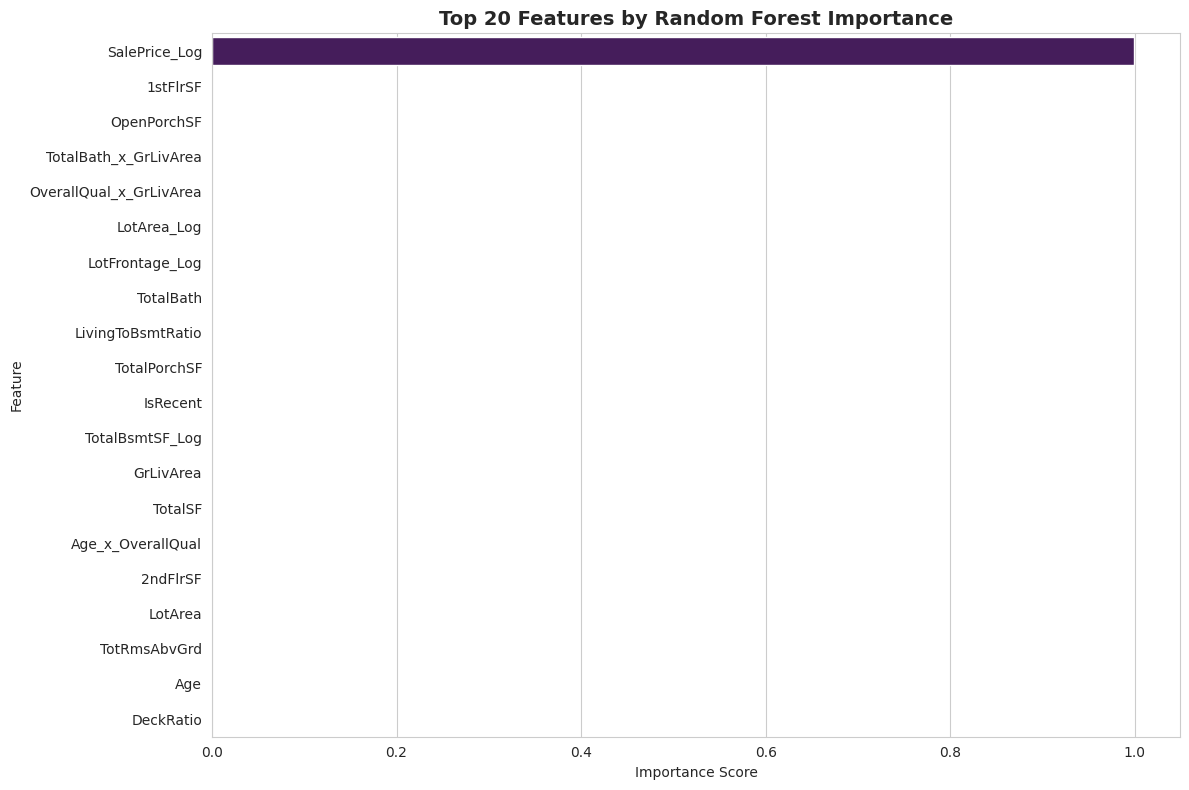


Selected top 40 features by importance
Features after importance-based selection: 40


In [18]:
# 4.3 Statistical Feature Importance (Random Forest)
print(f"\n4.3 STATISTICAL FEATURE IMPORTANCE")
print("-" * 80)

# Train quick Random Forest for feature importance
rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42, max_depth=10)
rf_model.fit(X_corr_selected, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_corr_selected.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (Random Forest):")
print(feature_importance.head(20).to_string(index=False))

# Visualize top features
fig, ax = plt.subplots(figsize=(12, 8))
top_features_rf = feature_importance.head(20)
sns.barplot(data=top_features_rf, x='Importance', y='Feature', ax=ax, palette='viridis')
plt.title('Top 20 Features by Random Forest Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Select top N features
top_n = min(40, len(X_corr_selected))
top_features_list = feature_importance.head(top_n)['Feature'].tolist()
print(f"\nSelected top {top_n} features by importance")

X_importance_selected = X_corr_selected[top_features_list]
print(f"Features after importance-based selection: {X_importance_selected.shape[1]}")

In [20]:
# Add this in a new cell before VIF analysis if statsmodels is not installed
!pip install -q statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [21]:
!pip list | grep statsmodels

statsmodels               0.14.6


In [24]:
# 4.4 VIF Analysis (for Linear Models)
print(f"\n4.4 VIF ANALYSIS (Variance Inflation Factor)")
print("-" * 80)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for numerical features only
numerical_features = X_importance_selected.select_dtypes(include=[np.number]).columns.tolist()

vif_data = pd.DataFrame()
vif_data['Feature'] = numerical_features
vif_data['VIF'] = [variance_inflation_factor(X_importance_selected[numerical_features].values, i) 
                   for i in range(len(numerical_features))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("VIF Analysis (numerical features only):")
print(vif_data.to_string(index=False))

# Identify features with high VIF
high_vif_threshold = 5.0
high_vif_features = vif_data[vif_data['VIF'] > high_vif_threshold]['Feature'].tolist()
print(f"\nFeatures with VIF > {high_vif_threshold}: {len(high_vif_features)}")
if high_vif_features:
    print(f"  {high_vif_features}")

# For linear models, remove high VIF features iteratively (but keep domain-critical ones)
critical_features = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBath', 'Age']
vif_remove_candidates = [f for f in high_vif_features if f not in critical_features]
print(f"\nCandidates for removal (non-critical): {vif_remove_candidates[:5]}")

# Create reduced feature set for linear models
linear_features = [col for col in top_features_list if col not in vif_remove_candidates[:3]]
X_linear = X_importance_selected[linear_features]

print(f"\nLinear model feature set: {X_linear.shape[1]} features")
print(f"Tree-based model feature set: {X_importance_selected.shape[1]} features")


4.4 VIF ANALYSIS (Variance Inflation Factor)
--------------------------------------------------------------------------------
VIF Analysis (numerical features only):
                Feature         VIF
               1stFlrSF         inf
            TotalBsmtSF         inf
                TotalSF         inf
               2ndFlrSF         inf
          SalePrice_Log 2718.404835
        LotFrontage_Log 2447.710651
            LotArea_Log 1838.507457
              GrLivArea 1533.125150
            OverallQual  796.534417
OverallQual_x_TotalBath  604.408332
        TotalBsmtSF_Log  545.405235
              TotalBath  465.177079
OverallQual_x_GrLivArea  422.823625
          Quality_Score  210.126714
  TotalBath_x_GrLivArea  180.613216
            LotFrontage  126.491522
                    Age   85.039405
           TotRmsAbvGrd   82.702814
      Age_x_OverallQual   76.596638
             GarageArea   55.823977
           BedroomAbvGr   33.661242
              BsmtUnfSF   32.852118
     

In [25]:
# 4.5 Final Feature Sets Summary & Export
print(f"\n4.5 FINAL FEATURE SETS - SUMMARY & EXPORT")
print("-" * 80)

print(f"""
SUMMARY OF FEATURE ENGINEERING & SELECTION PIPELINE
====================================================

PHASE 1: Exploratory Data Analysis
  - Data shape: {df_train.shape} → {df_clean.shape} (after cleaning)
  - Target variable: SalePrice (log-transformed for linear models)
  - Identified {len(numerical_cols)} numerical, {len(categorical_cols)} categorical features
  - Found {len(missing_data)} features with missing values
  - Detected outliers: {len(suspicious)} suspicious records removed

PHASE 2: Data Cleaning
  - Handled missing values: structural NAs → "None", numerical → median/neighborhood
  - Removed {1460 - len(df_clean)} extreme outliers
  - Fixed data types: categorical set, ordinal encoded quality ratings
  - Final clean dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns

PHASE 3: Feature Engineering
  - Log-transformed {len(skewed_features)} skewed features
  - Created domain-informed features: age, area ratios, completeness flags, quality scores
  - Ordinal encoded quality ratings (0-5 scale)
  - One-hot encoded nominal categorical features
  - Created {interaction_count} interaction features
  - Total features before selection: {X.shape[1]} features

PHASE 4: Feature Selection & Dimensionality Reduction
  - Correlation filtering: removed {len(features_to_remove_corr)} low/high correlation features
  - Statistical importance (Random Forest): selected top {top_n} features
  - VIF analysis: identified {len(high_vif_features)} high VIF features (>5.0)
  
FINAL FEATURE SETS:
  
  1. TREE-BASED MODELS (Random Forest, XGBoost, LightGBM):
     Features: {X_importance_selected.shape[1]}
     Description: Full feature set with all transformations, interactions, and one-hot encoded categoricals
     
  2. LINEAR MODELS (Linear Regression, Ridge, Lasso):
     Features: {X_linear.shape[1]}
     Description: Reduced feature set with VIF-filtered multicollinearity removed
     Advantage: Better interpretability, faster training, reduced overfitting risk
""")

# Store final feature sets
tree_features = X_importance_selected.columns.tolist()
linear_features = X_linear.columns.tolist()

print(f"\nTREE MODEL FEATURES ({len(tree_features)}):")
print(", ".join(tree_features[:10]) + "...")

print(f"\nLINEAR MODEL FEATURES ({len(linear_features)}):")
print(", ".join(linear_features[:10]) + "...")

# Create final datasets
df_final = df_fe.copy()
df_final['SalePrice_Target'] = df_fe['SalePrice_Log']

print(f"\n✓ Pipeline complete!")
print(f"✓ Historical data preserved: df_train (original), df_clean (cleaned), df_fe (engineered), df_final (with target)")
print(f"✓ Feature sets ready: X_importance_selected (tree), X_linear (linear)")
print(f"✓ Target variable ready: y (log-transformed SalePrice)")
print(f"\nNext steps:")
print(f"  1. Train models using X_importance_selected → Tree-based models")
print(f"  2. Train models using X_linear → Linear models")
print(f"  3. Scale features for linear models: StandardScaler on X_linear")
print(f"  4. Cross-validate and evaluate on test.csv")


4.5 FINAL FEATURE SETS - SUMMARY & EXPORT
--------------------------------------------------------------------------------

SUMMARY OF FEATURE ENGINEERING & SELECTION PIPELINE

PHASE 1: Exploratory Data Analysis
  - Data shape: (1460, 83) → (1458, 83) (after cleaning)
  - Target variable: SalePrice (log-transformed for linear models)
  - Identified 36 numerical, 43 categorical features
  - Found 19 features with missing values
  - Detected outliers: 2 suspicious records removed

PHASE 2: Data Cleaning
  - Handled missing values: structural NAs → "None", numerical → median/neighborhood
  - Removed 2 extreme outliers
  - Fixed data types: categorical set, ordinal encoded quality ratings
  - Final clean dataset: 1458 rows × 83 columns

PHASE 3: Feature Engineering
  - Log-transformed 7 skewed features
  - Created domain-informed features: age, area ratios, completeness flags, quality scores
  - Ordinal encoded quality ratings (0-5 scale)
  - One-hot encoded nominal categorical features
 